# 08 · Predicting outcomes from prior history

Research question: can information available before a fight add predictive value? This is sequential historical replay, not a betting system. A/B assignment is a deterministic outcome-independent hash of fight ID.

In [1]:
from pathlib import Path
import sys
import io
import pandas as pd
import numpy as np
from IPython.display import display, Image
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'data' / 'raw').exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.data_loader import load_raw, profile_sources, verify_raw, TABLES
from src.pipeline import prepare
from src.analysis import *
from src.visualization import *
def show(figure):
    buffer = io.BytesIO()
    figure.savefig(buffer, format='png', bbox_inches='tight')
    display(Image(data=buffer.getvalue()))
    plt.close(figure)

## Prepare chronological features

Each fighter history excludes the entire current date. No lifetime profile performance metrics or current-bout statistics enter the allowlist.

In [2]:
data = prepare(save=False)
fights, appearances = cohort(data)
print(f"Cohort: {len(fights):,} fights, {fights.event_id.nunique():,} events, {appearances.fighter_id.nunique():,} fighters")
print(f"Date range: {fights.event_date.min():%Y-%m-%d} to {fights.event_date.max():%Y-%m-%d}")

Cohort: 8,820 fights, 783 events, 2,735 fighters
Date range: 1994-03-11 to 2026-08-08


## Features and time splits

Train through 2019; validation 2020–2022 selects the model by log loss; test begins in 2023. Later test bouts may use earlier test results in history, as would be known at their dates. Model parameters stay fixed.

In [3]:
from src.modeling import model_frame, train_models, FEATURES
model_data = model_frame(data['fights'])
print('Allowed features:', FEATURES)
display(model_data.groupby('split',sort=False).agg(fights=('fight_id','size'), first_date=('event_date','min'), last_date=('event_date','max')))
display(model_data[FEATURES].isna().mean().rename('Missing share'))

Allowed features: ['age_diff', 'prior_ufc_fights_diff', 'prior_wins_diff', 'prior_losses_diff', 'prior_win_rate_diff', 'prior_ko_rate_diff', 'prior_submission_rate_diff', 'prior_win_streak_diff', 'prior_title_fights_diff', 'prior_sig_per_minute_diff', 'prior_sig_accuracy_diff', 'prior_td_per_15_diff', 'prior_td_accuracy_diff', 'weight_class']


,fights,first_date,last_date
split,,,
train,5366,1994-03-11,2019-12-21
validation,1447,2020-01-18,2022-12-17
test,1851,2023-01-14,2026-08-08


age_diff                      0.014197
prior_ufc_fights_diff         0.000000
prior_wins_diff               0.000000
prior_losses_diff             0.000000
prior_win_rate_diff           0.257271
prior_ko_rate_diff            0.253809
prior_submission_rate_diff    0.253809
prior_win_streak_diff         0.000000
prior_title_fights_diff       0.000000
prior_sig_per_minute_diff     0.254040
prior_sig_accuracy_diff       0.255656
prior_td_per_15_diff          0.254040
prior_td_accuracy_diff        0.380194
weight_class                  0.000000
Name: Missing share, dtype: float64

## Train interpretable candidates

Fit imputers, scaling and one-hot encoding only within training pipelines. Compare a majority baseline, logistic regression, a shallow tree, random forest and gradient boosting. No hyperparameters are selected on test results.

In [4]:
results = train_models(data['fights'])
display(results['model_metrics'])
import json
metadata = json.loads((TABLES/'model_metadata.json').read_text(encoding='utf-8'))
print('Validation-selected model:', metadata['selected_model'])

,model,split,n,accuracy,precision,recall,f1,roc_auc,brier_score,log_loss,accuracy_ci_low,accuracy_ci_high
0,Majority baseline,validation,1447,0.511403,0.000000,0.000000,0.000000,0.500000,0.249887,0.692921,NaN,NaN
1,Logistic regression,validation,1447,0.597789,0.604341,0.512023,0.554364,0.624663,0.238079,0.669189,NaN,NaN
2,Decision tree,validation,1447,0.592260,0.593600,0.524752,0.557057,0.617181,0.238655,0.670153,NaN,NaN
3,Random forest,validation,1447,0.597789,0.600969,0.526167,0.561086,0.637213,0.237869,0.668578,NaN,NaN
4,Gradient boosting,validation,1447,0.592951,0.594551,0.524752,0.557476,0.630265,0.237189,0.667098,NaN,NaN
5,Majority baseline,test,1851,0.495408,0.000000,0.000000,0.000000,0.500000,0.250141,0.693430,0.473681,0.518679
6,Logistic regression,test,1851,0.606159,0.615298,0.585653,0.600110,0.655900,0.231782,0.655297,0.583193,0.626329
7,Decision tree,test,1851,0.598595,0.608154,0.574946,0.591084,0.621935,0.238291,0.669056,0.576588,0.620970
8,Random forest,test,1851,0.611561,0.631258,0.553533,0.589846,0.654592,0.235154,0.662944,0.589034,0.633895
9,Gradient boosting,test,1851,0.603458,0.619332,0.555675,0.585779,0.651706,0.233179,0.658540,0.580557,0.625878


Validation-selected model: Gradient boosting


## Discrimination and calibration

Accuracy at the fixed 0.5 threshold and ROC-AUC measure different properties. Calibration and Brier score assess probability quality.

,actual,predicted,count
0,0,0,598
1,0,1,319
2,1,0,415
3,1,1,519


,mean_prediction,observed_a_win_rate
0,0.327778,0.280172
1,0.389824,0.372294
2,0.427842,0.454545
3,0.466246,0.482759
4,0.504891,0.532468
5,0.544798,0.584416
6,0.588687,0.593074
7,0.661880,0.737069


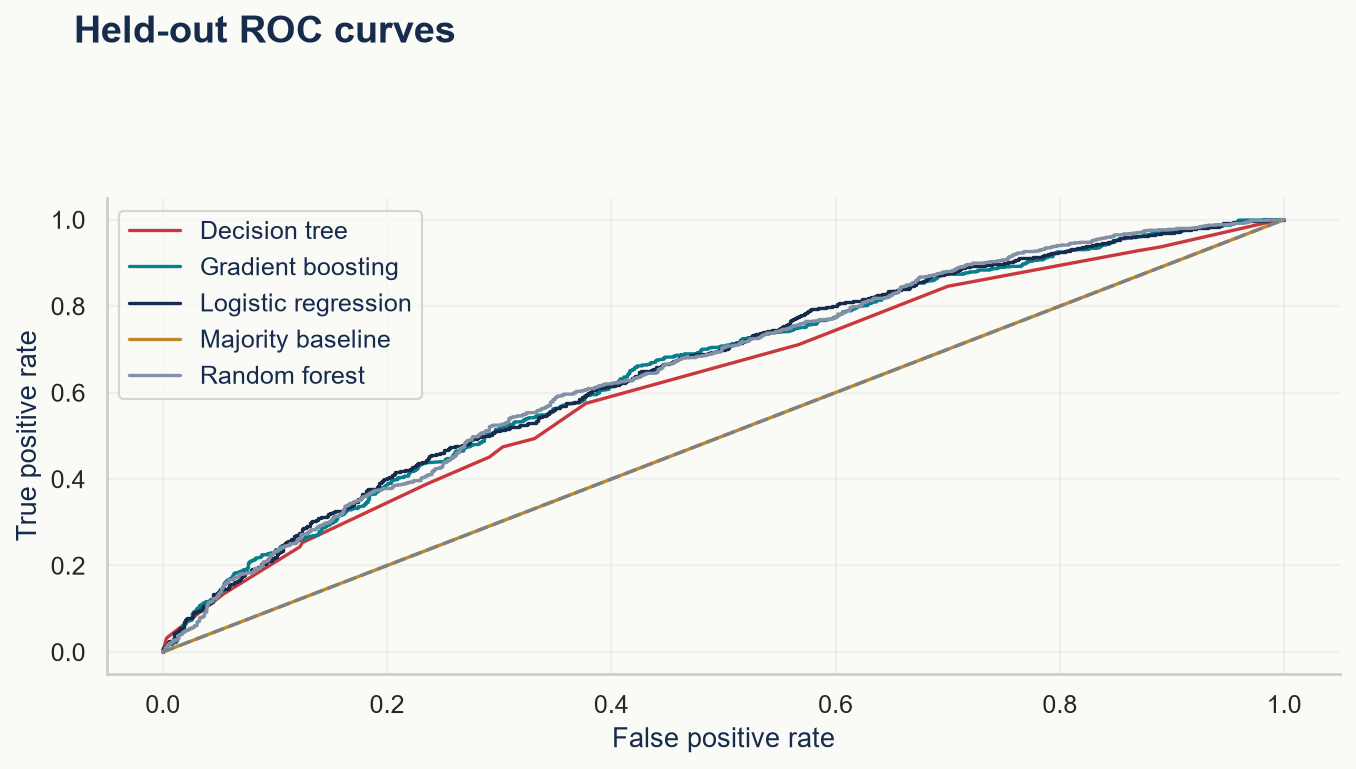

In [5]:
display(results['model_confusion'])
display(results['model_calibration'])
roc=results['roc_curves']; style()
fig,ax=plt.subplots(figsize=(9,5))
for name,rows in roc.groupby('model'):
    ax.plot(rows.false_positive_rate,rows.true_positive_rate,label=name)
ax.plot([0,1],[0,1],'--',color='gray');ax.legend()
ax.set(xlabel='False positive rate',ylabel='True positive rate')
show(finish(fig,'Held-out ROC curves'))

## Interpretation and failure modes

Logistic coefficients are standardized conditional associations. Correlated experience features complicate isolated interpretation. Report subgroup sample sizes and avoid ranking tiny groups.

In [6]:
display(results['model_coefficients'].sort_values('coefficient',key=abs,ascending=False).head(15))
display(results['model_subgroups'])

,feature,coefficient
30,categorical__weight_class_Other / unspecified,0.812966
0,numeric__age_diff,-0.318122
22,categorical__weight_class_Catch Weight,-0.315959
2,numeric__prior_wins_diff,0.241398
16,numeric__missingindicator_prior_submission_rat...,-0.197378
15,numeric__missingindicator_prior_ko_rate_diff,-0.197378
28,categorical__weight_class_Middleweight,-0.196154
17,numeric__missingindicator_prior_sig_per_minute...,0.187014
19,numeric__missingindicator_prior_td_per_15_diff,0.187014
7,numeric__prior_win_streak_diff,0.140460


,group,value,n,accuracy,precision,recall,f1,roc_auc,brier_score,log_loss
0,weight_class,Bantamweight,208,0.629808,0.620690,0.551020,0.583784,0.684740,0.226460,0.644593
1,weight_class,Featherweight,224,0.566964,0.579439,0.543860,0.561086,0.638995,0.235827,0.663980
2,weight_class,Flyweight,143,0.594406,0.612903,0.527778,0.567164,0.649257,0.234713,0.661830
3,weight_class,Heavyweight,128,0.656250,0.671642,0.671642,0.671642,0.692195,0.225096,0.641829
4,weight_class,Light Heavyweight,128,0.562500,0.542373,0.524590,0.533333,0.602887,0.241921,0.676672
5,weight_class,Lightweight,254,0.606299,0.555556,0.575221,0.565217,0.652294,0.232076,0.656346
6,weight_class,Middleweight,227,0.616740,0.708333,0.535433,0.609865,0.684016,0.230693,0.653383
7,weight_class,Welterweight,215,0.590698,0.595745,0.528302,0.560000,0.627272,0.235610,0.663382
8,weight_class,Women's Bantamweight,72,0.611111,0.636364,0.567568,0.600000,0.649035,0.234956,0.662616
9,weight_class,Women's Flyweight,97,0.608247,0.627907,0.551020,0.586957,0.630952,0.235982,0.664690


## Limits of historical replay

The snapshot has no timestamped corrections, injury reports, odds or historical rankings. Date of birth is assumed stable; profile stance, weight, reach and career averages are excluded from modeling. Previously seen athletes can appear in later periods, so this is not an unseen-fighter evaluation. Test performance must not guide further model selection without a new holdout.